In [39]:
import os
import numpy as np
import matplotlib.pyplot as plot
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from matplotlib.colors import Normalize

print(os.getcwd())
!jupyter labextension install jupyterlab-plotly

/vast/palmer/home.grace/kd766/quorum-sensing/notebooks
(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be removed in a future major version of JupyterLab.

Users should manage prebuilt extensions with package managers like pip and conda, and extension authors are encouraged to distribute their extensions as prebuilt packages 
/home/kd766/project/.conda/envs/quorum/lib/python3.12/site-packages/jupyterlab/debuglog.py:54: UserWarning: An error occurred.
  warnings.warn("An error occurred.")
/home/kd766/project/.conda/envs/quorum/lib/python3.12/site-packages/jupyterlab/debuglog.py:55: UserWarning: ValueError: Please install Node.js and npm before continuing installation. You may be able to install Node.js from your package manager, from conda, or directly from the Node.js website (https://nodejs.org).
  warnings.warn(msg[-1].strip())
/home/kd766/project/.conda/envs/quorum/lib/python3.12/site-packages/jupyterlab/debuglog.py:56: Use

In [141]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 10  # Default font size for general text
mpl.rcParams['axes.labelsize'] = 11 # Font size for axis labels
mpl.rcParams['xtick.labelsize'] = 9 # Font size for x-axis tick labels
mpl.rcParams['ytick.labelsize'] = 9 # Font size for y-axis tick labels
mpl.rcParams['legend.fontsize'] = 9 # Font size for legend
mpl.rcParams['axes.titlesize'] = 11 # Font size for plot title

In [214]:
def imshow3d(ax, array, value_direction='z', pos=0, norm=None, cmap=None):
    """
    Display a 2D array as a  color-coded 2D image embedded in 3d.

    The image will be in a plane perpendicular to the coordinate axis *value_direction*.

    Parameters
    ----------
    ax : Axes3D
        The 3D Axes to plot into.
    array : 2D numpy array
        The image values.
    value_direction : {'x', 'y', 'z'}
        The axis normal to the image plane.
    pos : float
        The numeric value on the *value_direction* axis at which the image plane is
        located.
    norm : `~matplotlib.colors.Normalize`, default: Normalize
        The normalization method used to scale scalar data. See `imshow()`.
    cmap : str or `~matplotlib.colors.Colormap`, default: :rc:`image.cmap`
        The Colormap instance or registered colormap name used to map scalar data
        to colors.
    """
    colors = plot.get_cmap(cmap)(array)

    if value_direction == 'x':
        nz, ny = array.shape
        zi, yi = np.mgrid[0:nz + 1, 0:ny + 1]
        xi = np.full_like(yi, pos)
    elif value_direction == 'y':
        nx, nz = array.shape
        xi, zi = np.mgrid[0:nx + 1, 0:nz + 1]
        yi = np.full_like(zi, pos)
    elif value_direction == 'z':
        ny, nx = array.shape
        yi, xi = np.mgrid[0:ny + 1, 0:nx + 1]
        zi = np.full_like(xi, pos)
    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")
    surf = ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, facecolors=colors, cmap=cmap, vmin=0, vmax=0.4, shade=False)
    return surf

## Graded Density - No Negative Feedback

In [7]:
!pwd

/vast/palmer/home.grace/kd766/quorum-sensing/notebooks


In [220]:
clouds_all = np.load("graded_seeding/noneg_gradedseeding_clouds_all.npy")
levels_all = np.load("graded_seeding/noneg_gradedseeding_levels_all.npy")
cloud_to_plot = clouds_all[-1, :, :]
level_to_plot = levels_all[-1, :, :]
density_distribution = lambda shape: np.vstack([x*np.ones(shape) for x in [0.05*x for x in range(1, 8)]])

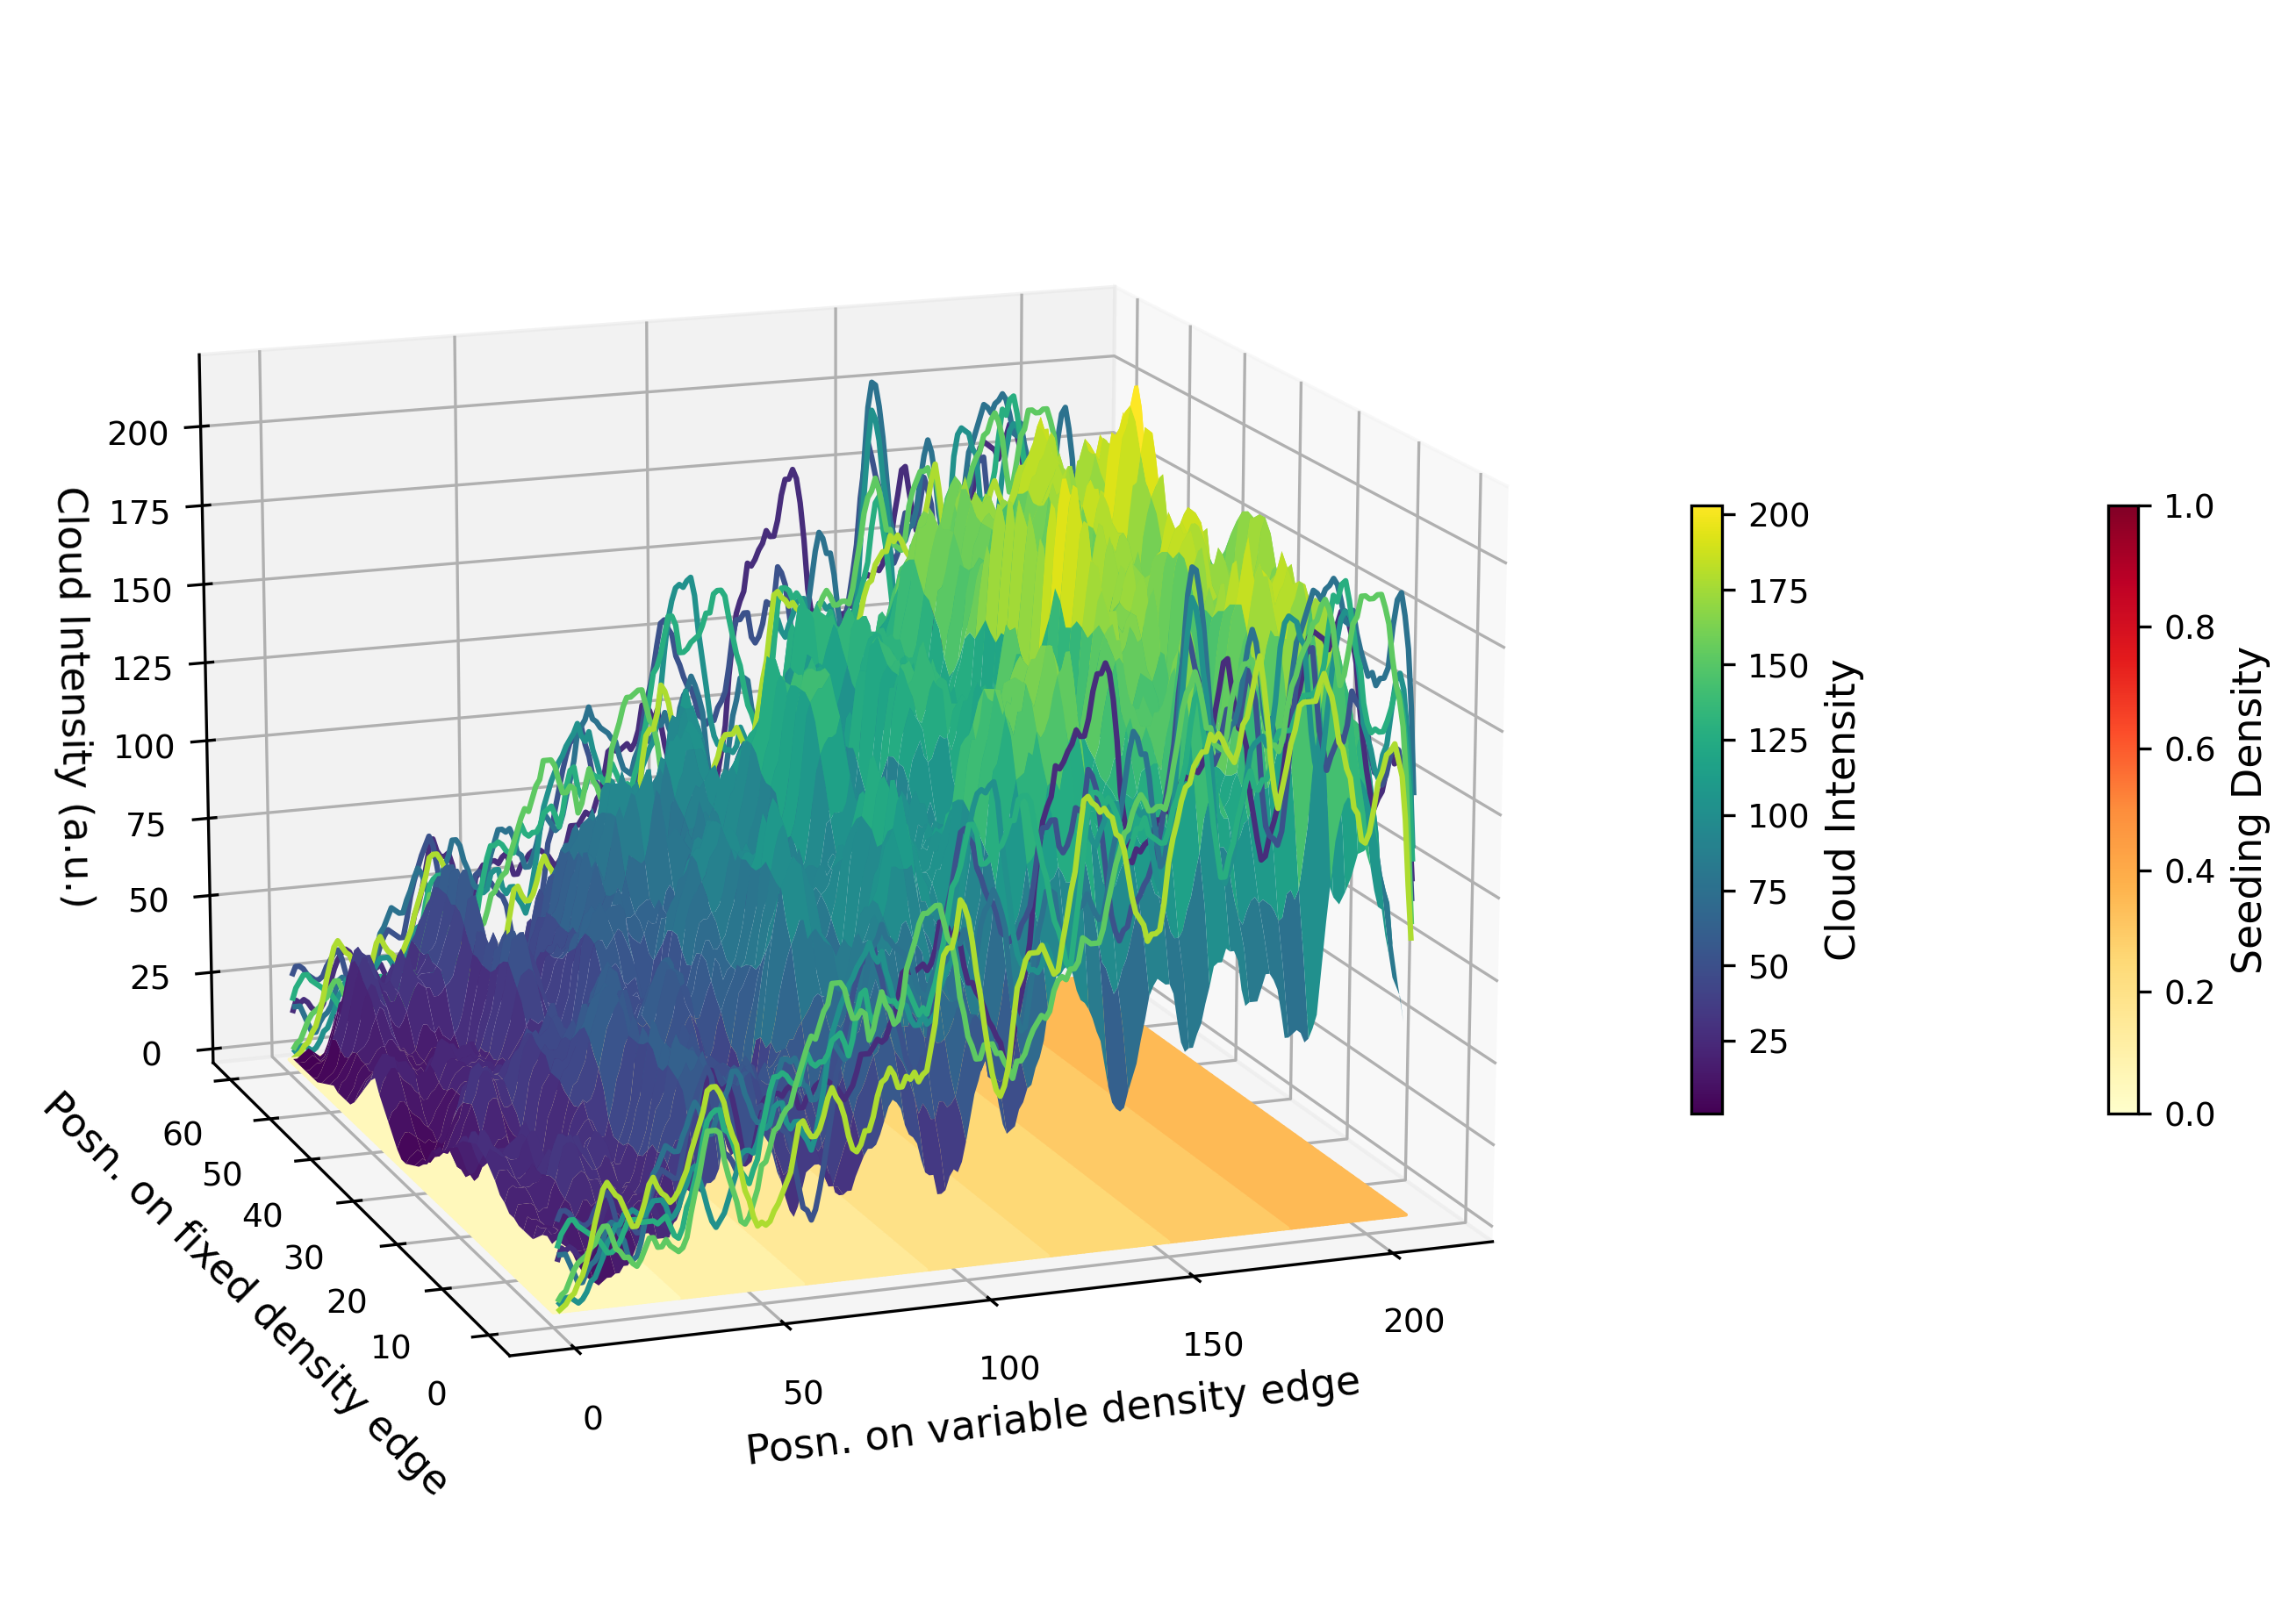

In [221]:
X, Y = np.meshgrid(np.arange(1, cloud_to_plot.shape[0]+1, 1), np.arange(1, cloud_to_plot.shape[1]+1, 1))

fig = plot.figure(figsize=(12, 12), dpi=300)
ax1 = fig.add_subplot(111, projection='3d')
ax1.view_init(elev=15, azim=250)
surf = ax1.plot_surface(X, Y, cloud_to_plot.T, cmap='viridis')
contour = ax1.contour(X, Y, cloud_to_plot.T, zdir='y', offset=0, cmap='viridis')
contour = ax1.contour(X, Y, cloud_to_plot.T, zdir='y', offset=60, cmap='viridis')
base = imshow3d(ax1, density_distribution((30, 60)).T, value_direction='z', cmap='YlOrRd')
# add colorbars
density_cbar = plot.colorbar(base, shrink=0.25, label='Seeding Density', location='right')
cntr_cbar = plot.colorbar(surf, shrink=0.25, label='Cloud Intensity', location='right')
# set axes
ax1.set_xlabel('Posn. on variable density edge')
ax1.set_ylabel('Posn. on fixed density edge')
ax1.set_zlabel('Cloud Intensity (a.u.)')
# show plot
plot.show()

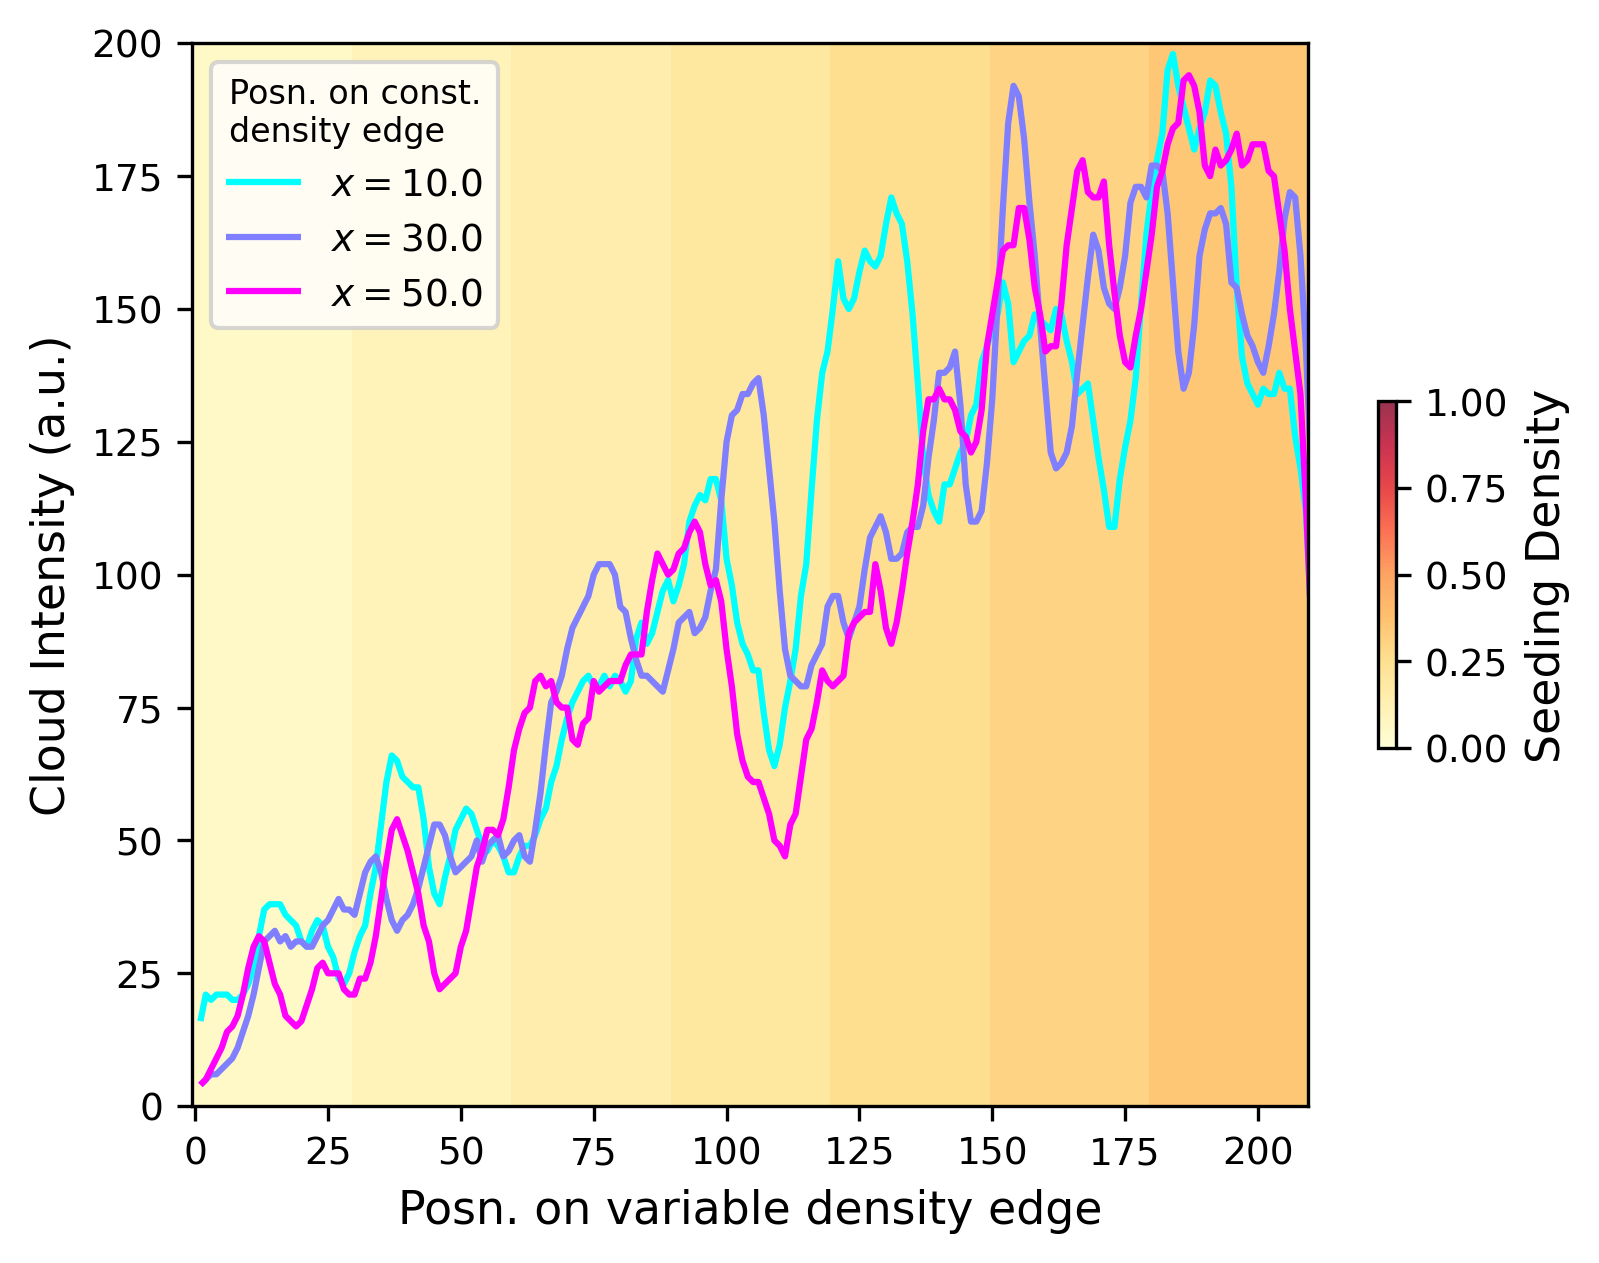

In [222]:
fig = plot.figure(figsize=(6, 6), dpi=300)
# plot contours.
contour = plot.gca().contour(X, cloud_to_plot.T, Y, levels=[10, 30, 50], cmap='cool')
h, l = contour.legend_elements()
plot.gca().legend(h, l, title="Posn. on const.\ndensity edge", loc='upper left', title_fontsize=8)
# plot density map.
im = plot.imshow(density_distribution((30, 200)).T, cmap='YlOrRd', origin='lower', alpha=0.8, vmin=0, vmax=1)
plot.xlabel("Posn. on variable density edge")
plot.ylabel("Cloud Intensity (a.u.)")
# add colorbars
density_cbar = plot.colorbar(im, shrink=0.25, label='Seeding Density', location='right')
plot.ylim([0, 200])
plot.show()

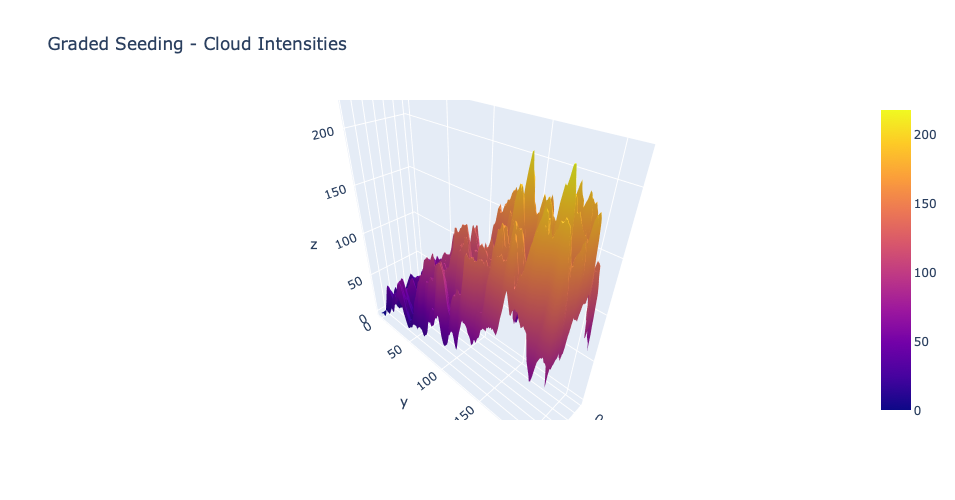

In [28]:
fig = go.Figure(data=[go.Surface(z=cloud_to_plot)])
fig.update_layout(title=dict(text='Graded Seeding - Cloud Intensities'), autosize=True,
                  width=500, height=500)
fig.show()

## Graded Density - With Negative Feedback

In [224]:
clouds_all = np.load("graded_seeding/gradedseeding_clouds_all.npy")
levels_all = np.load("graded_seeding/gradedseeding_levels_all.npy")
cloud_to_plot = clouds_all[-1, :, :]
level_to_plot = levels_all[-1, :, :]
density_distribution = lambda shape: np.vstack([x*np.ones(shape) for x in [0.05*x for x in range(1, 8)]])

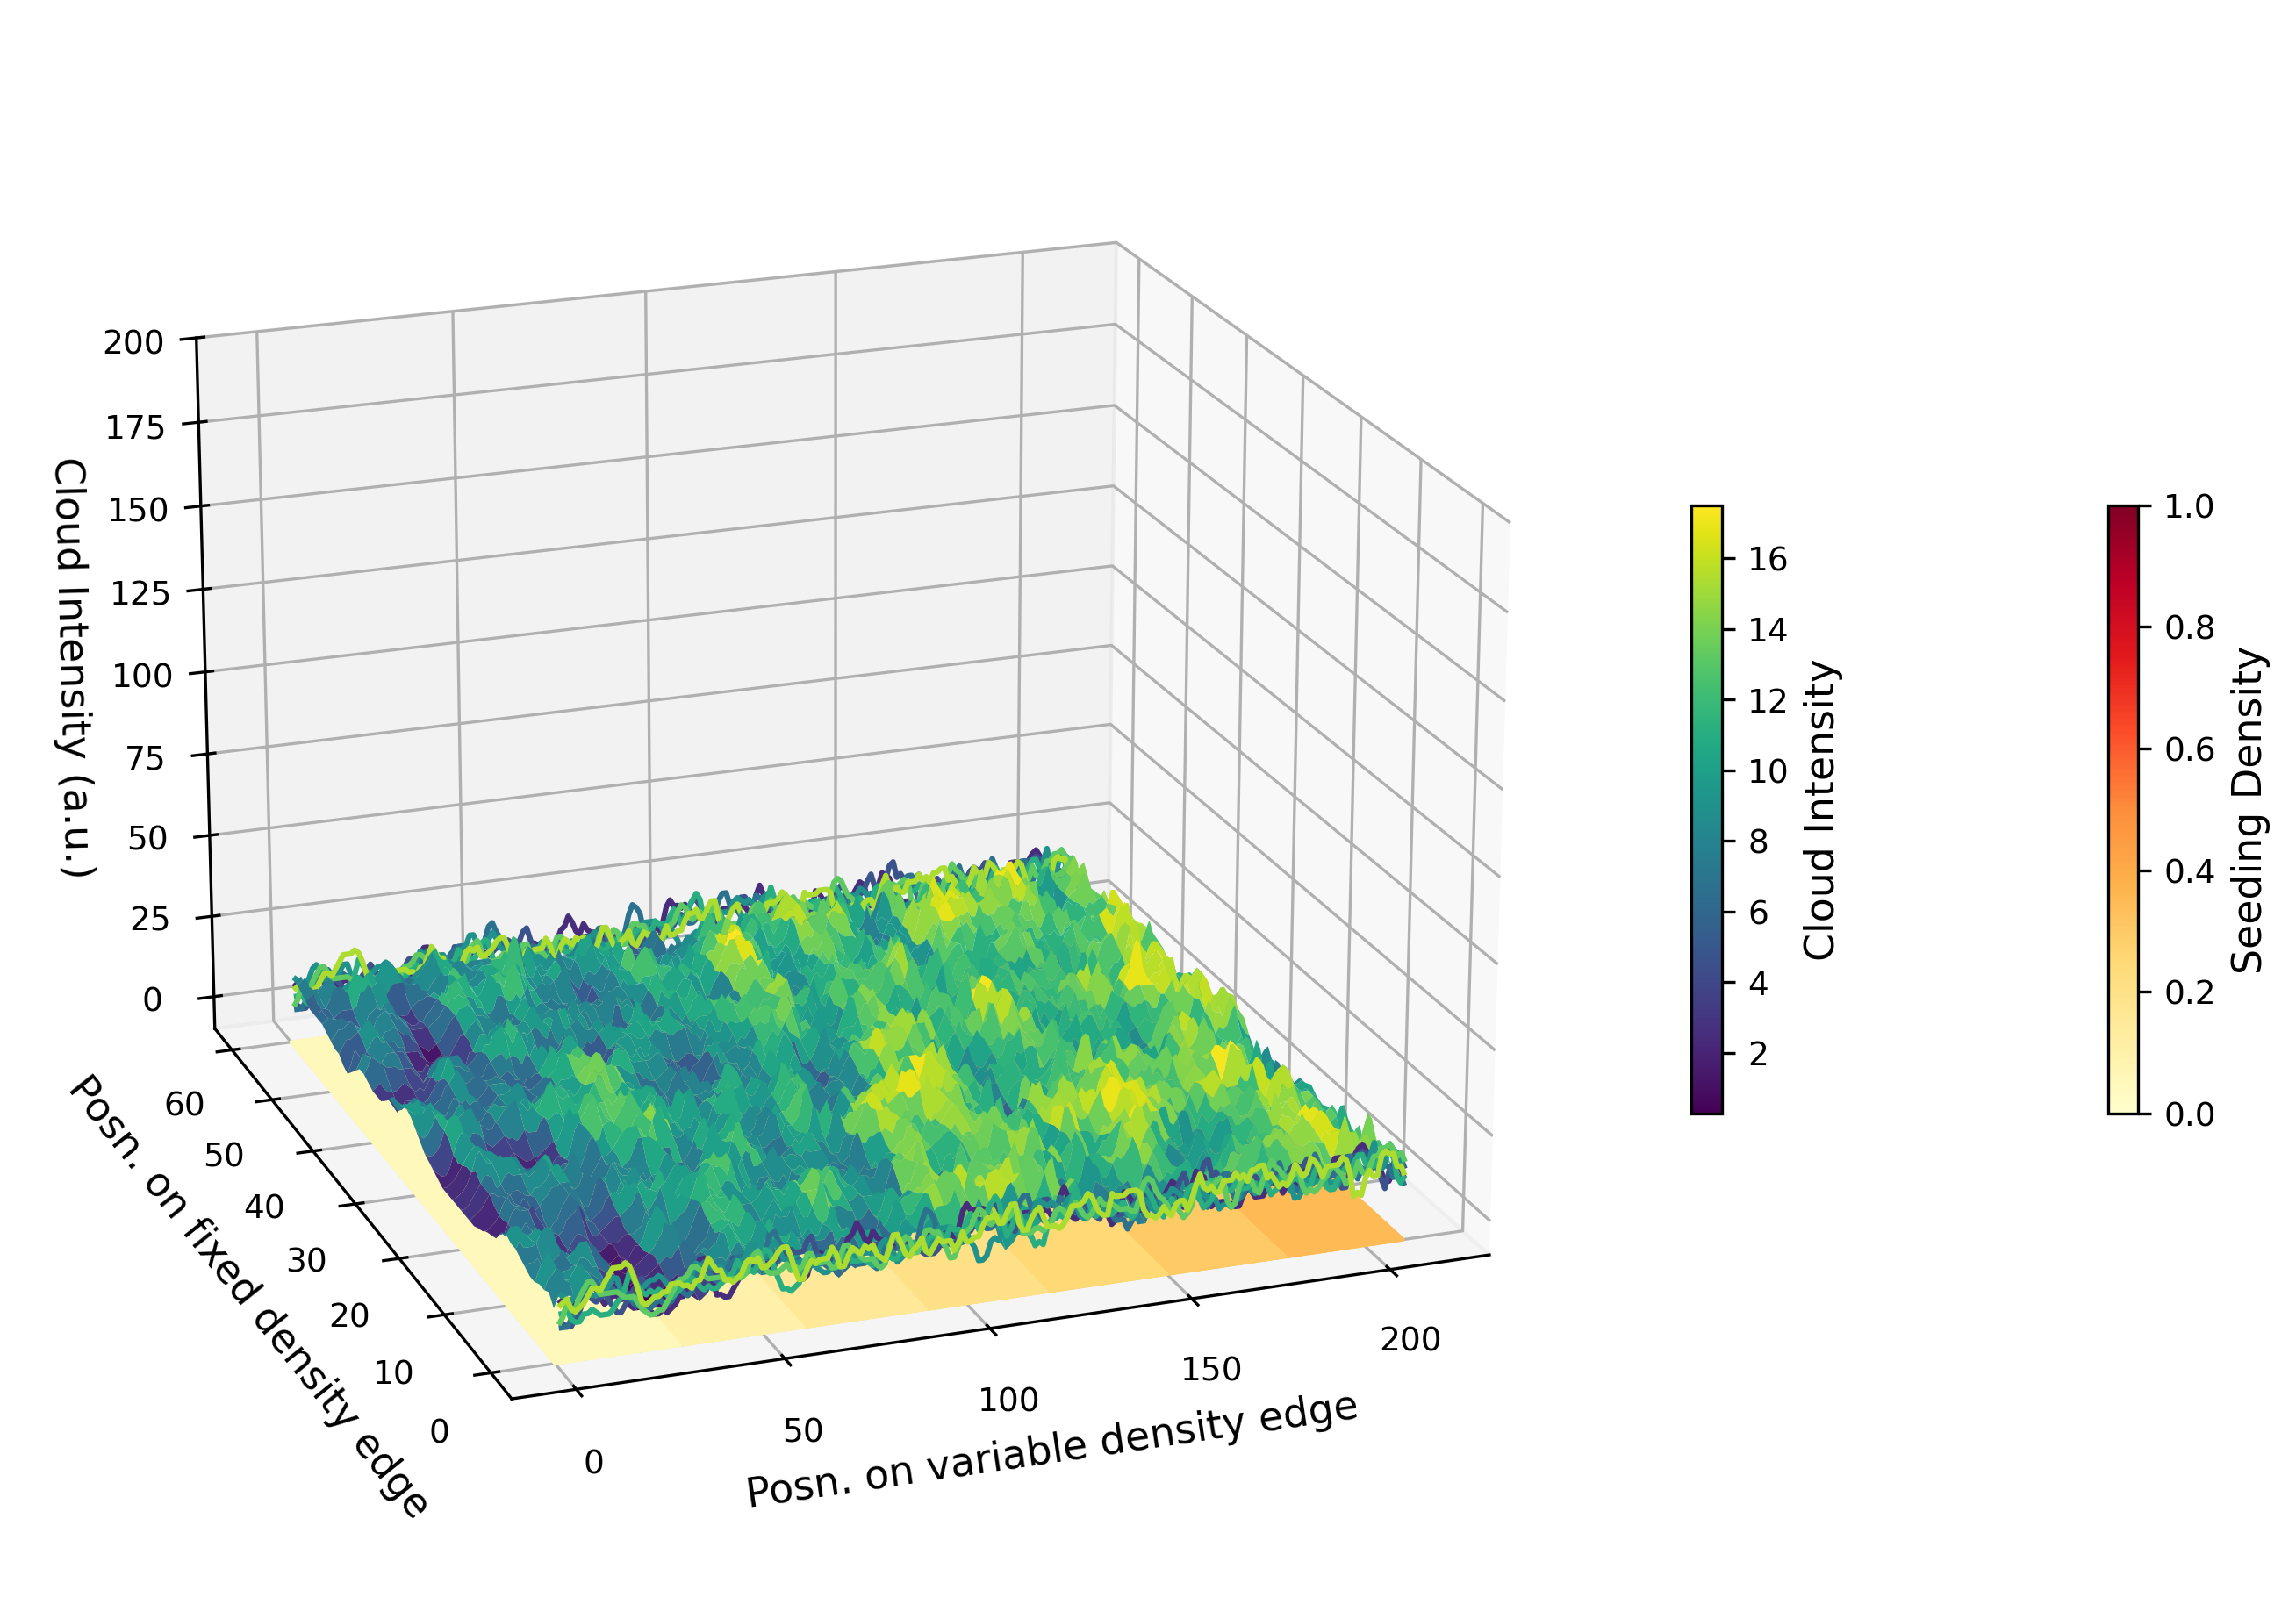

In [225]:
X, Y = np.meshgrid(np.arange(1, cloud_to_plot.shape[0]+1, 1), np.arange(1, cloud_to_plot.shape[1]+1, 1))
norm = Normalize()

fig = plot.figure(figsize=(12, 12), dpi=300)
ax1 = fig.add_subplot(111, projection='3d')
ax1.view_init(elev=20, azim=250)
surf = ax1.plot_surface(X, Y, cloud_to_plot.T, cmap='viridis')
contour = ax1.contour(X, Y, cloud_to_plot.T, zdir='y', offset=0, cmap='viridis')
contour = ax1.contour(X, Y, cloud_to_plot.T, zdir='y', offset=60, cmap='viridis')
base = imshow3d(ax1, density_distribution((30, 60)).T, value_direction='z', cmap='YlOrRd', pos=-10)
# add colorbars
density_cbar = plot.colorbar(base, shrink=0.25, label='Seeding Density', location='right')
cntr_cbar = plot.colorbar(surf, shrink=0.25, label='Cloud Intensity', location='right')
# set axes
ax1.set_xlabel('Posn. on variable density edge')
ax1.set_ylabel('Posn. on fixed density edge')
ax1.set_zlabel('Cloud Intensity (a.u.)')
ax1.set_zlim([-10, 200])
# show plot
plot.show()

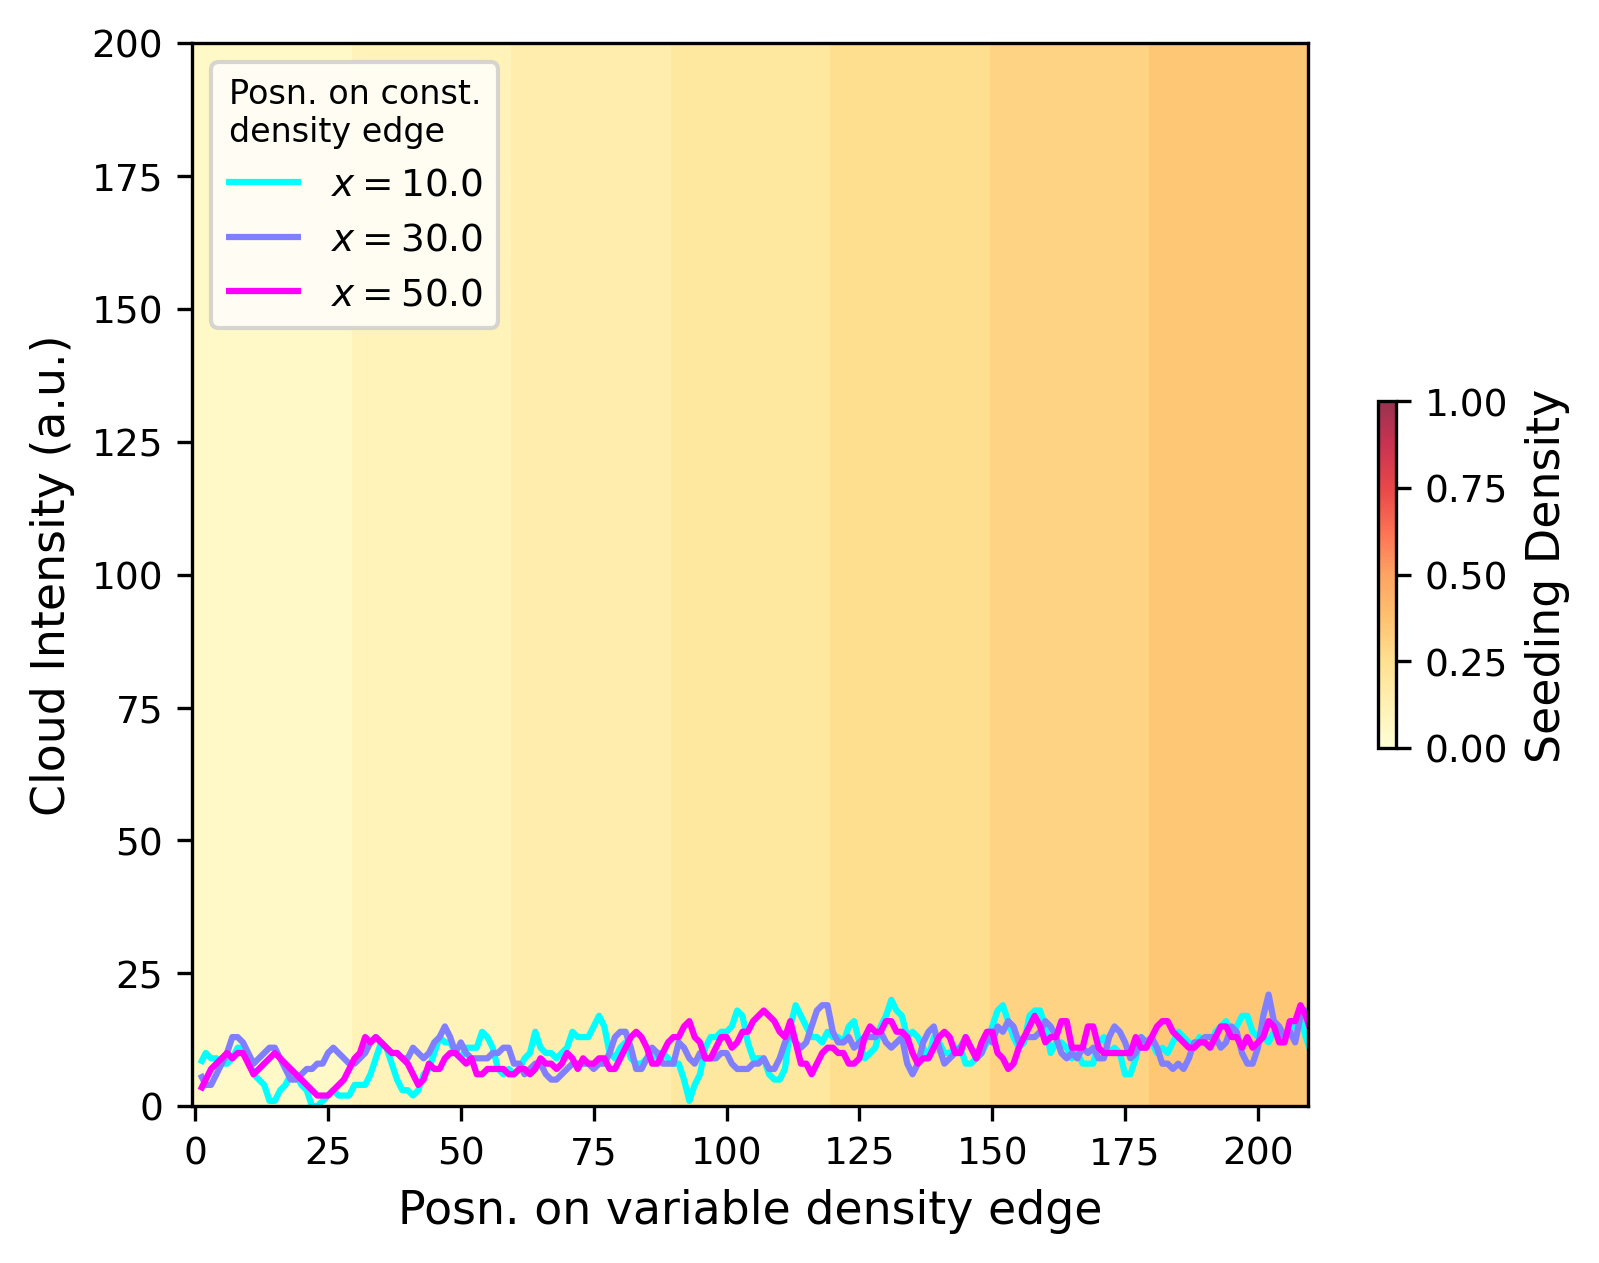

In [226]:
fig = plot.figure(figsize=(6, 6), dpi=300)
# plot contours.
contour = plot.gca().contour(X, cloud_to_plot.T, Y, levels=[10, 30, 50], cmap='cool')
h, l = contour.legend_elements()
plot.gca().legend(h, l, title="Posn. on const.\ndensity edge", loc='upper left', title_fontsize=8)
# plot density map.
im = plot.imshow(density_distribution((30, 200)).T, cmap='YlOrRd', origin='lower', alpha=0.8, vmin=0, vmax=1)
plot.xlabel("Posn. on variable density edge")
plot.ylabel("Cloud Intensity (a.u.)")
# add colorbars
density_cbar = plot.colorbar(im, shrink=0.25, label='Seeding Density', location='right')
plot.ylim([0, 200])
plot.show()

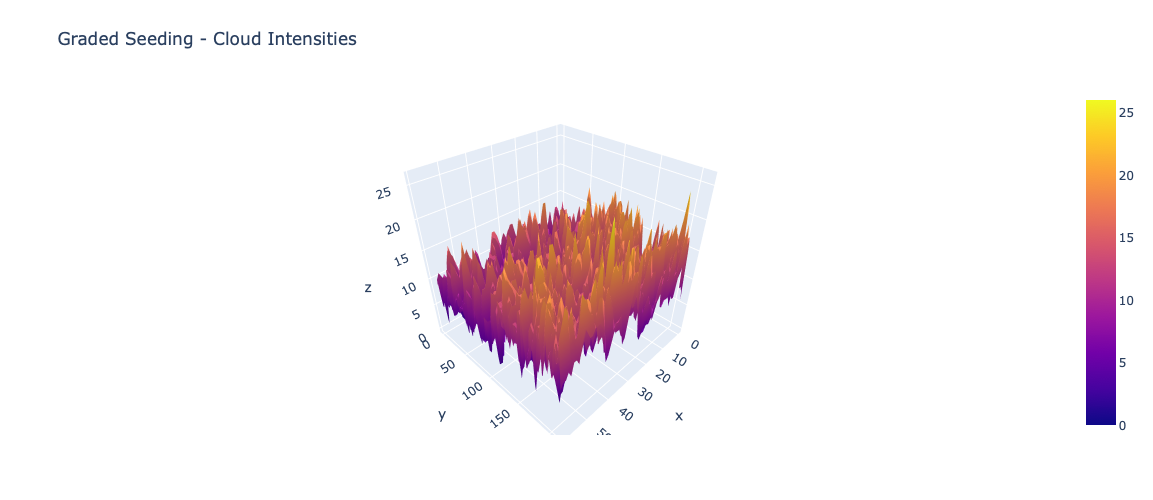

In [227]:
fig = go.Figure(data=[
    go.Surface(z=cloud_to_plot)])
fig.update_layout(title=dict(text='Graded Seeding - Cloud Intensities'), autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))
fig.show()